# Drug Release — All Five Models

Nested-CV comparison of GRU, LSTM, XGB-Time, XGB-NoTime, and XGB-MultiCurve.

- All models use **identical** drug-level `GroupKFold(n=10)` outer splits — verified and saved to `cv_folds.pkl`
- Results saved to `results_all_models.pkl`; reload cell at §3 skips retraining
- Plots: per-fold RMSE by AUC band (all five models) + representative low/high AUC release curves


## 0. Install

In [ ]:
!pip install -q optuna xgboost torch tqdm

## 1. Imports & config

In [1]:
import sys
sys.path.insert(0, '.')

import pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from itertools import combinations
from scipy.stats import wilcoxon

from drug_release_pipeline import (
    load_data, make_splits, verify_splits,
    run_gru, run_lstm, run_xgb_time, run_xgb_notime, run_xgb_multicurve,
    compare_models, wilcoxon_tests,
    SEED, NUM_INTERP_PTS, AUC_THRESHOLD,
)

warnings.filterwarnings('ignore')

RESULTS_PATH = Path('results_all_models.pkl')
FOLDS_PATH   = Path('cv_folds.pkl')

FILE_FORM = 'mp_dataset_processed_no_dupes.xlsx'
FILE_TIME = 'mp_dataset_processed_time_release_only.xlsx'

[drug_release_models] Using device: cuda
Ready.


## 2. Load data

In [2]:
(X, X_xgb_notime, X_xgb_time,
 y_timepoints, y_auc, y_class,
 y_nn, y_xgb,
 groups_xgb, aucs,
 drug_groups_form, drug_groups_xgb,
 _, feature_names) = load_data(FILE_FORM, FILE_TIME)

# y_nn is (321,11,1) for RNNs; multicurve needs (321,11)
y_curve = y_nn.squeeze()

normalized_times = np.linspace(0, 1, NUM_INTERP_PTS)
print(f'X_form {X.shape}  y_nn {y_nn.shape}  aucs {aucs.shape}')

X_form (321, 11)  y_nn (321, 11, 1)  aucs (321,)


## 3. CV splits — generate, save & verify

In [3]:
outer_splits, inner_splits_per_outer = make_splits(drug_groups_form)
verify_splits(outer_splits, drug_groups_form)

with open(FOLDS_PATH, "wb") as f:
    pickle.dump({"outer_splits": outer_splits,
                 "inner_splits_per_outer": inner_splits_per_outer}, f)
print(f"Folds saved to {FOLDS_PATH}")


[verify_splits] OK – 10 outer folds, 321 formulations, no drug leakage.
      Train forms  Test forms  Train drugs  Test drugs
Fold                                                  
1             272          49           87           1
2             290          31           79           9
3             290          31           78          10
4             291          30           79           9
5             291          30           79           9
6             291          30           78          10
7             291          30           78          10
8             291          30           78          10
9             291          30           78          10
10            291          30           78          10
Folds saved to cv_folds.pkl


## 4. XGB-MultiCurve (fifth model)

`drug_release_pipeline` covers four models; XGB-MultiCurve
(`MultiOutputRegressor(XGBRegressor)`) is defined inline and uses the
**same** `outer_splits` / `inner_splits_per_outer` from §3.


In [4]:
# run_xgb_multicurve is now provided by drug_release_pipeline
# See: from drug_release_pipeline import run_xgb_multicurve

## 5. Run all models

Reload guard: if `results_all_models.pkl` exists the cell reloads it
and verifies the saved folds match the current splits — no retraining.
Delete the file to force a full rerun.


In [5]:
if RESULTS_PATH.exists():
    with open(RESULTS_PATH, "rb") as f:
        all_results = pickle.load(f)
    print(f"Loaded {RESULTS_PATH}  (models: {list(all_results.keys())})")

    # Verify folds are identical
    with open(FOLDS_PATH, "rb") as f:
        saved = pickle.load(f)
    for i, ((tv_s, te_s), (tv_c, te_c)) in enumerate(
            zip(saved["outer_splits"], outer_splits), 1):
        assert np.array_equal(tv_s, tv_c) and np.array_equal(te_s, te_c),             f"Fold {i} mismatch!"
    print("✓ CV folds verified identical.")

else:
    all_results = {}

    all_results["GRU"] = run_gru(
        X_form, y_nn, outer_splits, inner_splits_per_outer, aucs=aucs)

    all_results["LSTM"] = run_lstm(
        X_form, y_nn, outer_splits, inner_splits_per_outer, aucs=aucs)

    all_results["XGB-Time"] = run_xgb_time(
        X_xgb_time, y_xgb, groups_xgb, drug_groups_xgb,
        outer_splits, inner_splits_per_outer, aucs=aucs)

    all_results["XGB-NoTime"] = run_xgb_notime(
        X_xgb_notime, y_xgb, groups_xgb, drug_groups_xgb,
        outer_splits, inner_splits_per_outer, aucs=aucs)

    all_results["XGB-Multi"] = run_xgb_multicurve(
        X_form, y_nn, outer_splits, inner_splits_per_outer, aucs=aucs)

    with open(RESULTS_PATH, "wb") as f:
        pickle.dump(all_results, f)
    print(f"\nSaved {RESULTS_PATH}")



===== FC-NN-GRU | OUTER FOLD 1 =====
  Best params: {'hidden_size': 128, 'num_layers': 3, 'dropout': 0.4, 'lr': 0.0001, 'batch_size': 32}
  MSE=0.0298  RMSE=0.1726  R²=0.7229  AdjR²=0.7171
  RMSE low  (AUC≤0.5) = 0.2550  (n_timepoints=77)
  RMSE high (AUC>0.5)  = 0.1547  (n_timepoints=462)

===== FC-NN-GRU | OUTER FOLD 2 =====
  Best params: {'hidden_size': 32, 'num_layers': 3, 'dropout': 0.4, 'lr': 0.0001, 'batch_size': 16}
  MSE=0.0342  RMSE=0.1850  R²=0.7073  AdjR²=0.6975
  RMSE low  (AUC≤0.5) = 0.2004  (n_timepoints=187)
  RMSE high (AUC>0.5)  = 0.1645  (n_timepoints=154)

===== FC-NN-GRU | OUTER FOLD 3 =====
  Best params: {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.4, 'lr': 0.0001, 'batch_size': 128}
  MSE=0.0334  RMSE=0.1828  R²=0.6252  AdjR²=0.6126
  RMSE low  (AUC≤0.5) = 0.1550  (n_timepoints=55)
  RMSE high (AUC>0.5)  = 0.1877  (n_timepoints=286)

===== FC-NN-GRU | OUTER FOLD 4 =====
  Best params: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.3, 'lr': 0.001, 'ba

## 6. Summary metrics table

In [6]:
df_compare = compare_models(all_results)

summary = (df_compare.groupby("model")[["rmse","adj_r2","rmse_low","rmse_high"]]
           .agg(["mean","std"]))
summary.columns = [" ".join(c) for c in summary.columns]
summary = summary.reindex(MODEL_ORDER)
display(summary.style
    .background_gradient(subset=["rmse mean"], cmap="RdYlGn_r")
    .background_gradient(subset=["adj_r2 mean"], cmap="RdYlGn")
    .format("{:.4f}"))



=== Model Comparison ===
                 mse                rmse                  r2              adj_r2            rmse_low           rmse_high          
                mean       std      mean       std      mean       std      mean       std      mean       std      mean       std
model                                                                                                                             
GRU         0.033605  0.006237  0.182590  0.017193  0.664861  0.055458  0.653726  0.057823  0.188209  0.038833  0.175973  0.020462
LSTM        0.034825  0.007129  0.185794  0.018424  0.651173  0.071215  0.639544  0.074179  0.190428  0.044451  0.180104  0.025710
XGB-Multi   0.031752  0.005209  0.177656  0.014548  0.683678  0.040019  0.673178  0.041859  0.206518  0.047275  0.159967  0.018323
XGB-NoTime  0.102886  0.011244  0.320330  0.017467 -0.025240  0.044156 -0.059078  0.046316  0.331705  0.042492  0.313851  0.011134
XGB-Time    0.031483  0.006432  0.176603  0.018076  0.687

,rmse mean,rmse std,adj_r2 mean,adj_r2 std,rmse_low mean,rmse_low std,rmse_high mean,rmse_high std
model,,,,,,,,
GRU,0.1826,0.0172,0.6537,0.0578,0.1882,0.0388,0.1760,0.0205
LSTM,0.1858,0.0184,0.6395,0.0742,0.1904,0.0445,0.1801,0.0257
XGB-Time,0.1766,0.0181,0.6759,0.0532,0.2106,0.0386,0.1620,0.0144
XGB-NoTime,0.3203,0.0175,-0.0591,0.0463,0.3317,0.0425,0.3139,0.0111
XGB-Multi,0.1777,0.0145,0.6732,0.0419,0.2065,0.0473,0.1600,0.0183


## 7. Per-fold RMSE by AUC band

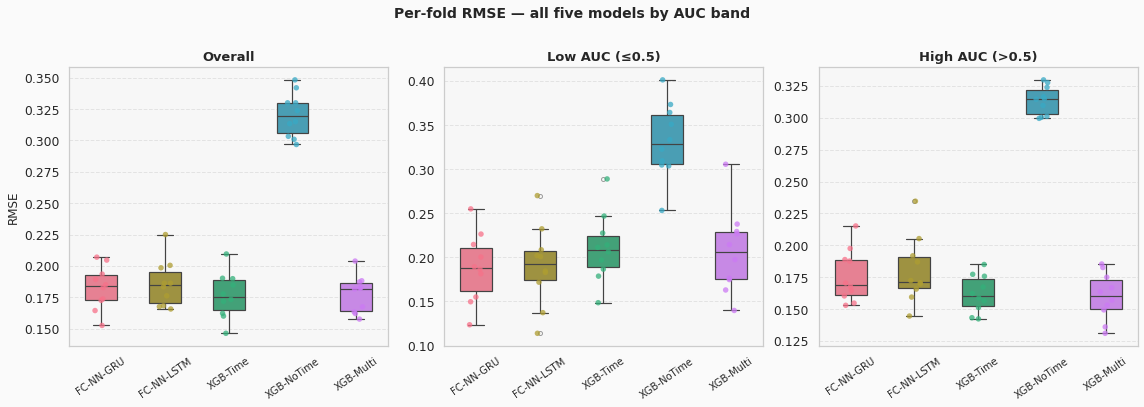

In [13]:
MODEL_ORDER  = ["FC-NN-GRU", "FC-NN-LSTM", "XGB-Time", "XGB-NoTime", "XGB-Multi"]
MODEL_COLORS = dict(zip(MODEL_ORDER, _pal))

all_results = {
    {"GRU": "FC-NN-GRU", "LSTM": "FC-NN-LSTM"}.get(k, k): v
    for k, v in all_results.items()
}

rows = []
for key in MODEL_ORDER:
    r = all_results[key]
    for fold_i, (rmse_all, rl, rh) in enumerate(
            zip(r["rmse"], r["rmse_low"], r["rmse_high"]), 1):
        rows += [
            {"Model": key, "Fold": fold_i, "Band": "Overall",          "RMSE": rmse_all},
            {"Model": key, "Fold": fold_i, "Band": "Low AUC (≤0.5)",   "RMSE": rl},
            {"Model": key, "Fold": fold_i, "Band": "High AUC (>0.5)",  "RMSE": rh},
        ]
df_long = pd.DataFrame(rows)
df_long["Model"] = pd.Categorical(df_long["Model"], categories=MODEL_ORDER, ordered=True)

band_order = ["Overall", "Low AUC (≤0.5)", "High AUC (>0.5)"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=False)
fig.patch.set_facecolor("#FAFAFA")

for ax, band in zip(axes, band_order):
    sub = df_long[df_long["Band"] == band]
    sns.boxplot(data=sub, x="Model", y="RMSE",
                palette=MODEL_COLORS, width=0.5, linewidth=1.2,
                flierprops=dict(marker="o", markersize=4, alpha=0.5),
                ax=ax)
    sns.stripplot(data=sub, x="Model", y="RMSE",
                  palette=MODEL_COLORS, size=5.5, alpha=0.75, jitter=True, ax=ax)
    ax.set_title(band, fontsize=13, fontweight="bold", pad=7)
    ax.set_xlabel("")
    ax.set_ylabel("RMSE" if ax is axes[0] else "", fontsize=12)
    ax.tick_params(axis="x", rotation=35, labelsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.45)
    ax.set_facecolor("#F7F7F7")
    for sp in ax.spines.values(): sp.set_edgecolor("#CCCCCC")

fig.suptitle("Per-fold RMSE — all five models by AUC band",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("rmse_per_auc_band.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()


## 8. Representative release curves — low & high AUC

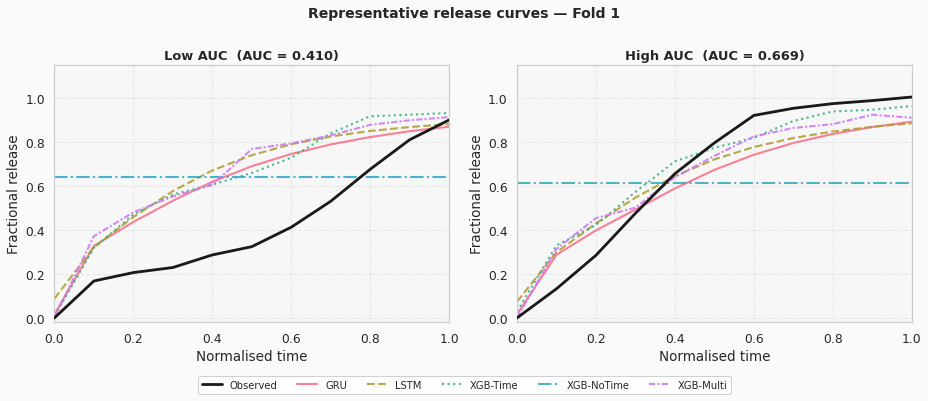

In [8]:
# Pick fold 1 test set; choose the median-AUC formulation from each stratum
test_idx_f1 = outer_splits[0][1]
fold_aucs   = aucs[test_idx_f1]

def _median_idx(mask):
    cands = np.where(mask)[0]
    if len(cands) == 0: return None
    return cands[np.argmin(np.abs(fold_aucs[cands] - np.median(fold_aucs[cands])))]

i_low  = _median_idx(fold_aucs <= AUC_THRESHOLD)
i_high = _median_idx(fold_aucs >  AUC_THRESHOLD)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#FAFAFA")

for ax, (i_local, label, auc_val) in zip(axes, [
    (i_low,  "Low AUC",  fold_aucs[i_low]),
    (i_high, "High AUC", fold_aucs[i_high]),
]):
    # True curve — same across all models (use GRU targets as reference)
    true_curve = all_results["GRU"]["targets"][0].reshape(-1, NUM_INTERP_PTS)[i_local]
    ax.plot(normalized_times, true_curve, "k-", lw=2.8, label="Observed", zorder=5)

    for i, key in enumerate(MODEL_ORDER):
        pred_fold = all_results[key]["preds"][0].reshape(-1, NUM_INTERP_PTS)
        ax.plot(normalized_times, pred_fold[i_local],
                linestyle=LINESTYLES[i], lw=2.1,
                color=MODEL_COLORS[key], label=key, alpha=0.88)

    ax.set(xlim=(0,1), ylim=(-0.02, 1.15),
           xlabel="Normalised time", ylabel="Fractional release",
           title=f"{label}  (AUC = {auc_val:.3f})")
    ax.title.set_fontsize(13); ax.title.set_fontweight("bold")
    ax.grid(linestyle="--", alpha=0.4)
    ax.set_facecolor("#F7F7F7")
    for sp in ax.spines.values(): sp.set_edgecolor("#CCCCCC")

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=6,
           bbox_to_anchor=(0.5, -0.07), frameon=True, framealpha=0.9, fontsize=10)
fig.suptitle("Representative release curves — Fold 1",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("representative_curves.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()


## 9. Wilcoxon signed-rank tests (paired folds)

In [9]:
for metric, title in [("rmse",      "Overall RMSE"),
                      ("rmse_low",  "RMSE — Low AUC (≤0.5)"),
                      ("rmse_high", "RMSE — High AUC (>0.5)"),
                      ("adj_r2",    "Adjusted R²")]:
    wilcoxon_tests(all_results, metric=metric)



=== Wilcoxon tests on rmse ===
  GRU vs LSTM: W=18.0, p=0.3750  ns
  GRU vs XGB-Time: W=18.0, p=0.3750  ns
  GRU vs XGB-NoTime: W=0.0, p=0.0020  **
  GRU vs XGB-Multi: W=19.0, p=0.4316  ns
  LSTM vs XGB-Time: W=17.0, p=0.3223  ns
  LSTM vs XGB-NoTime: W=0.0, p=0.0020  **
  LSTM vs XGB-Multi: W=17.0, p=0.3223  ns
  XGB-Time vs XGB-NoTime: W=0.0, p=0.0020  **
  XGB-Time vs XGB-Multi: W=27.0, p=1.0000  ns
  XGB-NoTime vs XGB-Multi: W=0.0, p=0.0020  **

=== Wilcoxon tests on rmse_low ===
  GRU vs LSTM: W=23.0, p=0.6953  ns
  GRU vs XGB-Time: W=11.0, p=0.1055  ns
  GRU vs XGB-NoTime: W=0.0, p=0.0020  **
  GRU vs XGB-Multi: W=8.0, p=0.0488  **
  LSTM vs XGB-Time: W=15.0, p=0.2324  ns
  LSTM vs XGB-NoTime: W=0.0, p=0.0020  **
  LSTM vs XGB-Multi: W=13.0, p=0.1602  ns
  XGB-Time vs XGB-NoTime: W=0.0, p=0.0020  **
  XGB-Time vs XGB-Multi: W=27.0, p=1.0000  ns
  XGB-NoTime vs XGB-Multi: W=0.0, p=0.0020  **

=== Wilcoxon tests on rmse_high ===
  GRU vs LSTM: W=19.0, p=0.4316  ns
  GRU vs XGB-Tim

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

XGB-Time vs. XGB-NoTime: Wilcoxon test (paired samples) with Bonferroni correction, P_val:7.812e-03 Stat=0.000e+00
XGB-NoTime vs. XGB-Multi: Wilcoxon test (paired samples) with Bonferroni correction, P_val:7.812e-03 Stat=0.000e+00
FC-NN-LSTM vs. XGB-NoTime: Wilcoxon test (paired samples) with Bonferroni correction, P_val:7.812e-03 Stat=0.000e+00
FC-NN-GRU vs. XGB-NoTime: Wilcoxon test (paired samples) with Bonferroni correction, P_val:7.812e-03 Stat=0.000e+00


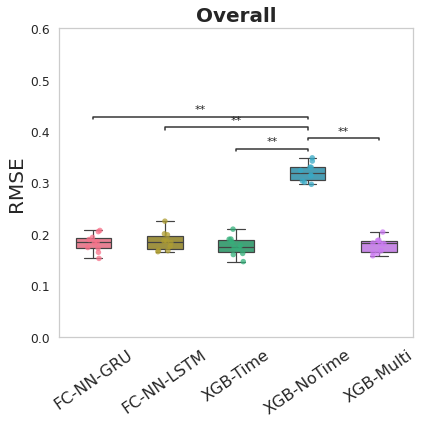

Saved rmse_overall.png
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

XGB-Time vs. XGB-NoTime: Wilcoxon test (paired samples) with Bonferroni correction, P_val:7.812e-03 Stat=0.000e+00
XGB-NoTime vs. XGB-Multi: Wilcoxon test (paired samples) with Bonferroni correction, P_val:7.812e-03 Stat=0.000e+00
FC-NN-LSTM vs. XGB-NoTime: Wilcoxon test (paired samples) with Bonferroni correction, P_val:7.812e-03 Stat=0.000e+00
FC-NN-GRU vs. XGB-NoTime: Wilcoxon test (paired samples) with Bonferroni correction, P_val:7.812e-03 Stat=0.000e+00


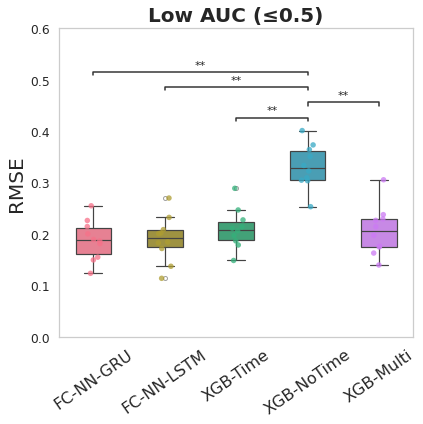

Saved rmse_low_auc.png
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

XGB-Time vs. XGB-NoTime: Wilcoxon test (paired samples) with Bonferroni correction, P_val:7.812e-03 Stat=0.000e+00
XGB-NoTime vs. XGB-Multi: Wilcoxon test (paired samples) with Bonferroni correction, P_val:7.812e-03 Stat=0.000e+00
FC-NN-LSTM vs. XGB-NoTime: Wilcoxon test (paired samples) with Bonferroni correction, P_val:7.812e-03 Stat=0.000e+00
FC-NN-GRU vs. XGB-NoTime: Wilcoxon test (paired samples) with Bonferroni correction, P_val:7.812e-03 Stat=0.000e+00


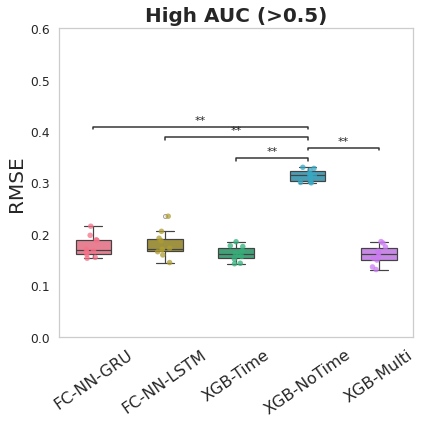

Saved rmse_high_auc.png


In [47]:
from itertools import combinations
from scipy.stats import wilcoxon
from statannotations.Annotator import Annotator

def get_sig_pairs(all_results, metric, correction="bonferroni"):
    names = list(all_results.keys())
    scores = {n: np.array(all_results[n][metric]) for n in names}
    all_pairs = list(combinations(names, 2))
    threshold = 0.05 / len(all_pairs) if correction == "bonferroni" else 0.05
    sig = []
    for a, b in all_pairs:
        mask = ~(np.isnan(scores[a]) | np.isnan(scores[b]))
        if mask.sum() < 2:
            continue
        _, p = wilcoxon(scores[a][mask], scores[b][mask])
        if p < threshold:
            sig.append((a, b))
    return sig

rows = []
for key in MODEL_ORDER:
    r = all_results[key]
    for fold_i, (rmse_all, rl, rh) in enumerate(
            zip(r["rmse"], r["rmse_low"], r["rmse_high"]), 1):
        rows += [
            {"Model": key, "Fold": fold_i, "Band": "Overall",         "RMSE": rmse_all},
            {"Model": key, "Fold": fold_i, "Band": "Low AUC (≤0.5)",  "RMSE": rl},
            {"Model": key, "Fold": fold_i, "Band": "High AUC (>0.5)", "RMSE": rh},
        ]
df_long = pd.DataFrame(rows)
df_long["Model"] = pd.Categorical(df_long["Model"], categories=MODEL_ORDER, ordered=True)

band_order  = ["Overall",  "Low AUC (≤0.5)",  "High AUC (>0.5)"]
metric_keys = ["rmse",     "rmse_low",         "rmse_high"]
fnames      = ["rmse_overall.png", "rmse_low_auc.png", "rmse_high_auc.png"]

for band, metric, fname in zip(band_order, metric_keys, fnames):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    fig.patch.set_facecolor("#FAFAFA")

    sub = df_long[df_long["Band"] == band]

    sns.boxplot(data=sub, x="Model", y="RMSE",
                palette=MODEL_COLORS, width=0.5, linewidth=1.2,
                flierprops=dict(marker="o", markersize=4, alpha=0.5),
                ax=ax)
    sns.stripplot(data=sub, x="Model", y="RMSE",
                  palette=MODEL_COLORS, size=5.5, alpha=0.75, jitter=True, ax=ax)

    sig_pairs = get_sig_pairs(all_results, metric, correction="bonferroni")
    if sig_pairs:
        annotator = Annotator(ax, sig_pairs, data=sub,
                              x="Model", y="RMSE", order=MODEL_ORDER)
        annotator.configure(test="Wilcoxon", text_format="star",
                            loc="inside", comparisons_correction="bonferroni",
                            line_height=0.02, text_offset=2, fontsize=11)
        annotator.apply_and_annotate()

    ax.set_ylim(0, 0.6)
    ax.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
    ax.set_title(band, fontsize=20, fontweight="bold", pad=7)
    ax.set_xlabel("")
    ax.set_ylabel("RMSE", fontsize=20)
    ax.tick_params(axis="x", rotation=35, labelsize=16)
    ax.grid(False)
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")
    for sp in ax.spines.values():
        sp.set_edgecolor("#CCCCCC")
        sp.set_visible(True)
    plt.tight_layout()
    plt.savefig(fname, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved {fname}")

In [15]:
!pip install -q statannotations

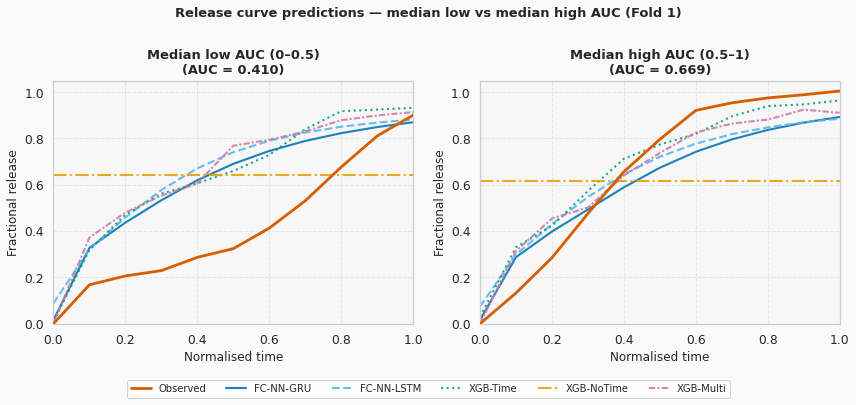

In [29]:
# Wong colorblind-safe palette
WONG = {
    "black":        "#000000",
    "orange":       "#E69F00",
    "sky_blue":     "#56B4E9",
    "green":        "#009E73",
    "yellow":       "#F0E442",
    "blue":         "#0072B2",
    "vermillion":   "#D55E00",  # red-orange
    "pink":         "#CC79A7",  # purple-pink
}

MODEL_COLORS_CB = {
    "FC-NN-GRU"  : WONG["blue"],
    "FC-NN-LSTM" : WONG["sky_blue"],
    "XGB-Time"   : WONG["green"],
    "XGB-NoTime" : WONG["orange"],
    "XGB-Multi"  : WONG["pink"],
}
OBSERVED_COLOR = WONG["vermillion"]  # red-orange for observed

# ── Plot ──────────────────────────────────────────────────────────────────────
test_idx_f1 = outer_splits[0][1]
fold_aucs   = aucs[test_idx_f1]

low_mask  = fold_aucs <= 0.5
high_mask = fold_aucs >  0.5

def median_idx(mask):
    cands = np.where(mask)[0]
    return cands[np.argmin(np.abs(fold_aucs[cands] - np.median(fold_aucs[cands])))]

i_low  = median_idx(low_mask)
i_high = median_idx(high_mask)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor("#FAFAFA")

for ax, (i_local, label, auc_val) in zip(axes, [
    (i_low,  "Median low AUC (0–0.5)",  fold_aucs[i_low]),
    (i_high, "Median high AUC (0.5–1)", fold_aucs[i_high]),
]):
    true_curve = all_results["FC-NN-GRU"]["targets"][0].reshape(-1, NUM_INTERP_PTS)[i_local]
    ax.plot(normalized_times, true_curve, color=OBSERVED_COLOR,
            linestyle="-", lw=2.8, label="Observed", zorder=5)

    for key, ls in zip(MODEL_ORDER, LINESTYLES):
        pred = all_results[key]["preds"][0].reshape(-1, NUM_INTERP_PTS)[i_local]
        ax.plot(normalized_times, pred,
                linestyle=ls, lw=2.1, color=MODEL_COLORS_CB[key], label=key, alpha=0.88)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Normalised time", fontsize=12)
    ax.set_ylabel("Fractional release", fontsize=12)
    ax.set_title(f"{label}\n(AUC = {auc_val:.3f})", fontsize=13, fontweight="bold", pad=7)
    ax.grid(linestyle="--", alpha=0.4)
    ax.set_facecolor("#F7F7F7")
    for sp in ax.spines.values(): sp.set_edgecolor("#CCCCCC")

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=6,
           bbox_to_anchor=(0.5, -0.08), frameon=True, framealpha=0.9, fontsize=10)
fig.suptitle("Release curve predictions — median low vs median high AUC (Fold 1)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("representative_curves.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

In [40]:
test_idx_f1 = outer_splits[3][1]
fold_aucs   = aucs[test_idx_f1]
n_test      = len(test_idx_f1)
sorted_order = np.argsort(fold_aucs)

def plot_formulation(rank):
    i_local  = sorted_order[rank]
    form_idx = test_idx_f1[i_local]
    auc_val  = aucs[form_idx]

    fig, ax = plt.subplots(figsize=(6, 5))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    true_curve = all_results["FC-NN-GRU"]["targets"][1].reshape(-1, NUM_INTERP_PTS)[i_local]
    ax.plot(normalized_times, true_curve, color=OBSERVED_COLOR,
            linestyle="-", lw=2.8, label="Observed", zorder=5)

    for key, ls in zip(MODEL_ORDER, LINESTYLES):
        pred = all_results[key]["preds"][1].reshape(-1, NUM_INTERP_PTS)[i_local]
        ax.plot(normalized_times, pred,
                linestyle=ls, lw=2.1, color=MODEL_COLORS_CB[key], label=key, alpha=0.88)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Normalized time", fontsize=20)
    ax.set_ylabel("Fractional release", fontsize=20)
    ax.set_title(f"Rank {rank+1}/{n_test}  |  Formulation {form_idx}  |  AUC = {auc_val:.3f}",
                 fontsize=12, fontweight="bold")
    ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
    ax.grid(False)

    for sp in ax.spines.values():
        sp.set_visible(True)

    plt.tight_layout()
    plt.show()

interact(plot_formulation, rank=IntSlider(min=0, max=n_test-1, step=1, value=0,
                                          description="AUC rank",
                                          style={"description_width": "auto"},
                                          layout={"width": "500px"}))

interactive(children=(IntSlider(value=0, description='AUC rank', layout=Layout(width='500px'), max=29, style=S…

<function __main__.plot_formulation(rank)>

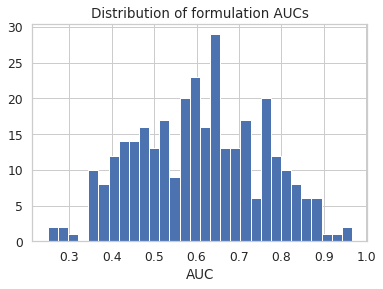

min=0.249  max=0.966  mean=0.607


In [36]:
import matplotlib.pyplot as plt
plt.hist(aucs, bins=30)
plt.xlabel("AUC")
plt.title("Distribution of formulation AUCs")
plt.show()
print(f"min={aucs.min():.3f}  max={aucs.max():.3f}  mean={aucs.mean():.3f}")